# **Brain Stroke Prediction**

**Data Dictionary**

Training Data(df): Brain Stroke Data

Training Unseen Data(df_unseen): Brain Stroke Unseen Data

**Import Libraries**

In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder


**Load Datasets**

In [100]:
# Load the training dataset
df = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_data.csv")

df.head(5)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [101]:
# Load the unseen dataset
df_unseen = pd.read_csv("./processed_datasets/brain_stroke/brain_stroke_unseen.csv")

df_unseen.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


**EDA**

In [142]:
# Function to display basic information about the DataFrame
def data_info(df):
    print("DataFrame Info:") # info
    print(df.info())
    print("\nDataFrame Shape:") # shape
    print(df.shape)
    print("DataFrame Columns:") # columns
    print(df.columns.tolist())  
    print("DataFrame Missing Values:") # missing values
    print(df.isna().sum())

data_info(df)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4482 entries, 0 to 4481
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4482 non-null   object 
 1   age                4482 non-null   float64
 2   hypertension       4482 non-null   int64  
 3   heart_disease      4482 non-null   int64  
 4   ever_married       4482 non-null   object 
 5   work_type          4482 non-null   object 
 6   Residence_type     4482 non-null   object 
 7   avg_glucose_level  4482 non-null   float64
 8   bmi                4482 non-null   float64
 9   smoking_status     4482 non-null   object 
 10  stroke             4482 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 385.3+ KB
None

DataFrame Shape:
(4482, 11)
DataFrame Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_s

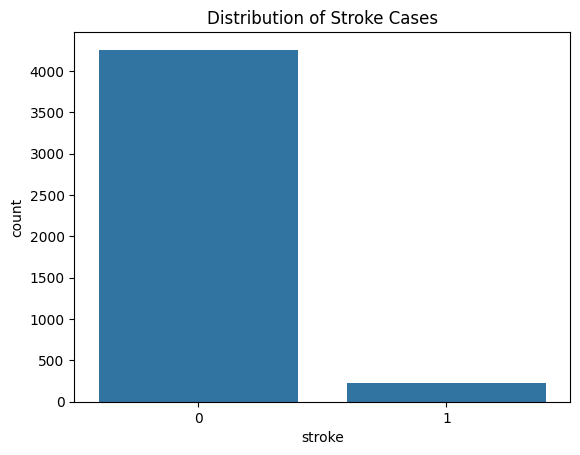

stroke
0    95.02
1     4.98
Name: proportion, dtype: float64

In [ ]:
# Check for class imbalance
sns.countplot (x = "stroke", data = df)
plt.title("Distribution of Stroke Cases")
plt.show()

# percentage
round(df["stroke"].value_counts(normalize=True) * 100, 2)

Numerical Data EDA

In [140]:
# Function to display statistics of numerical features
def numerical_stats(df):
    num_cols = df.select_dtypes(include=["float64"]).columns
    print("Numerical Features Statistics:")
    print(df[num_cols].describe().round(2))

numerical_stats(df)

Numerical Features Statistics:
           age  avg_glucose_level      bmi
count  4482.00            4482.00  4482.00
mean     43.45             105.76    28.47
std      22.59              44.94     6.76
min       0.08              55.12    14.00
25%      26.00              77.19    23.60
50%      45.00              91.68    28.10
75%      61.00             113.64    32.58
max      82.00             267.76    48.90


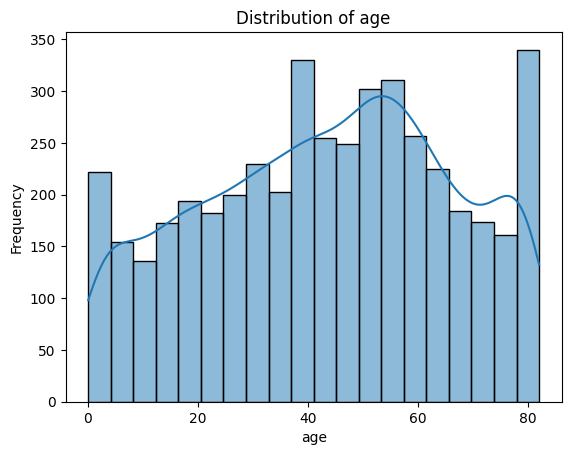

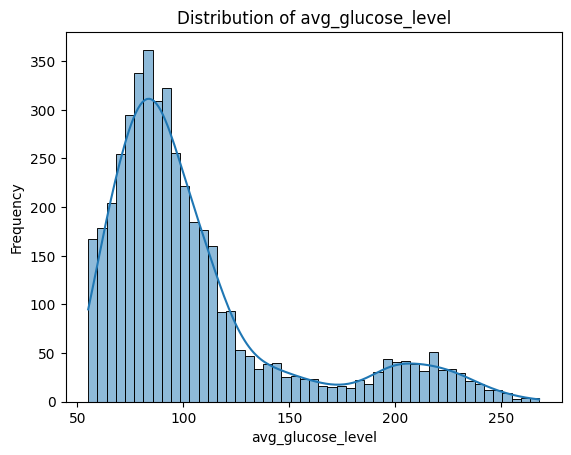

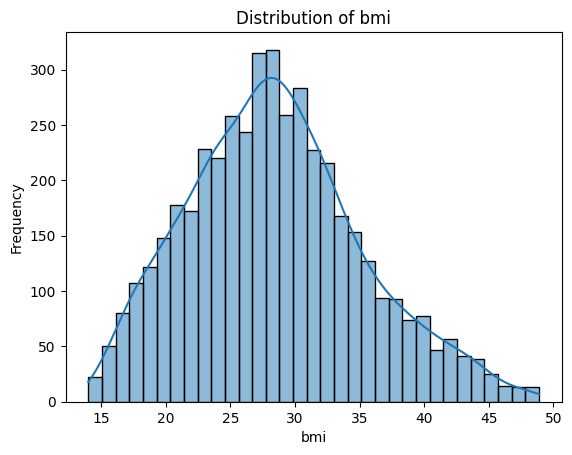

In [ ]:
# Visualise numerical features
def plot_numeric_distributions(df):
    num_cols = df.select_dtypes(include=["float64"]).columns
    
    for col in num_cols:
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

plot_numeric_distributions(df)

In [114]:
# Function to display value counts and percentages for categorical features
def categorical_value_counts(df):
    for col in df.select_dtypes(include=["object", "int64"]).columns:
        print(f"Value counts for '{col}':")
        
        counts = df[col].value_counts()
        perc = df[col].value_counts(normalize=True) * 100
        
        summary = pd.DataFrame({
            "Count": counts,
            "Percentage (%)": round(perc, 2)
        })
        
        print(summary)
        print("\n")
        
categorical_value_counts(df)

Value counts for 'gender':
        Count  Percentage (%)
gender                       
Female   2600           58.01
Male     1882           41.99


Value counts for 'hypertension':
              Count  Percentage (%)
hypertension                       
0              4041           90.16
1               441            9.84


Value counts for 'heart_disease':
               Count  Percentage (%)
heart_disease                       
0               4237           94.53
1                245            5.47


Value counts for 'ever_married':
              Count  Percentage (%)
ever_married                       
Yes            2951           65.84
No             1531           34.16


Value counts for 'work_type':
               Count  Percentage (%)
work_type                           
Private         2571           57.36
Self-employed    721           16.09
children         602           13.43
Govt_job         588           13.12


Value counts for 'Residence_type':
                Coun

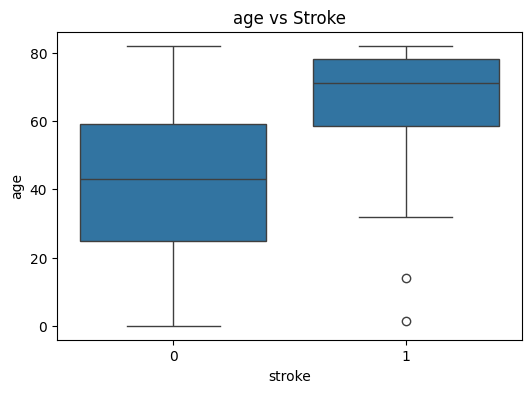

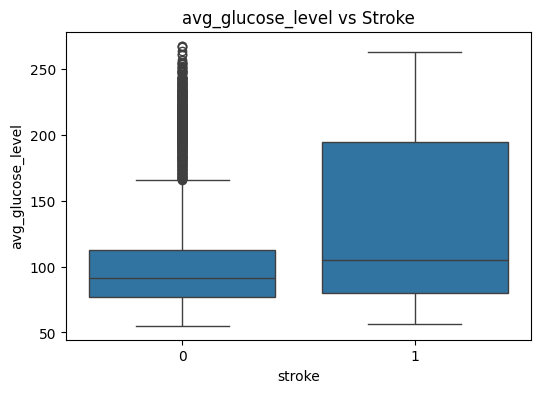

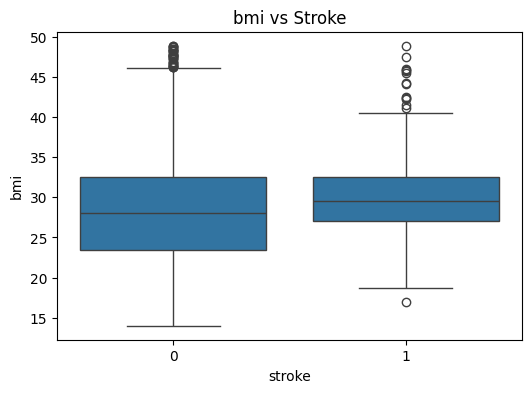

In [144]:
num_cols = ["age", "avg_glucose_level", "bmi"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="stroke", y=col, data=df)
    plt.title(f"{col} vs Stroke")
    plt.show()

Categorical Data EDA

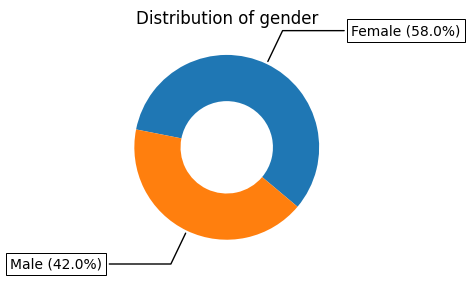

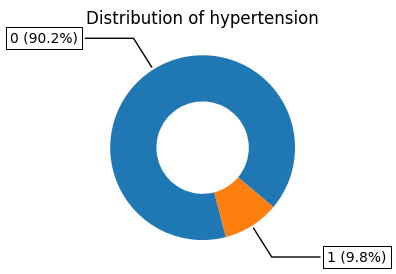

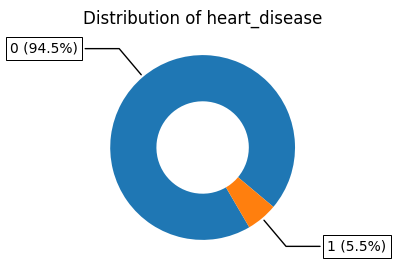

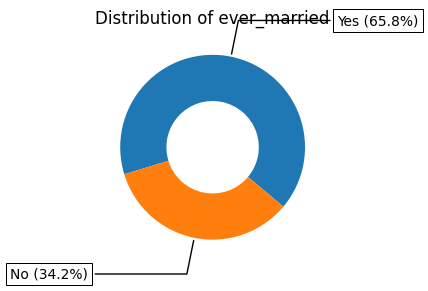

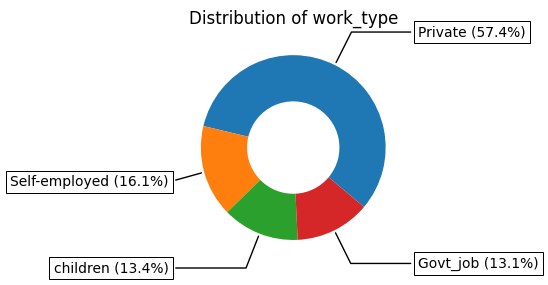

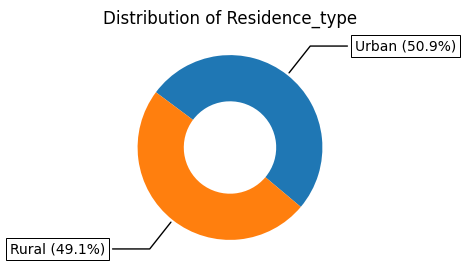

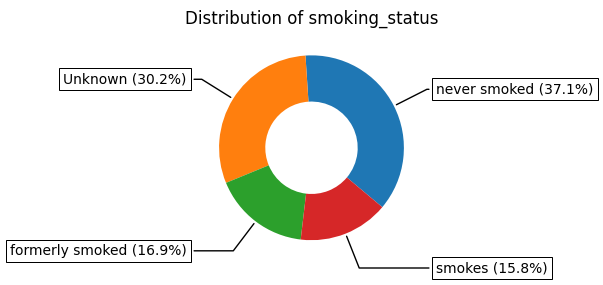

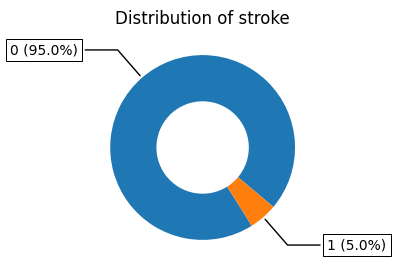

In [ ]:
# Visualise categorical features
# Pie chart code reference from: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html

def visualise_categorical_features(df):
    
    cat_cols = df.select_dtypes(include=["object", "int64"]).columns
    
    for column in cat_cols:
        
        counts = df[column].value_counts()
        
        labels = counts.index.astype(str)
        data = counts.values
        total = data.sum()
        
        fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))
        
        wedges, texts = ax.pie(
            data,
            wedgeprops=dict(width=0.5),
            startangle=-40
        )
        
        # annotation style
        bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
        kw = dict(
            arrowprops=dict(arrowstyle="-"),
            bbox=bbox_props,
            zorder=0,
            va="center"
        )
        
        for i, p in enumerate(wedges):
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"
            
            kw["arrowprops"].update({"connectionstyle": connectionstyle})
            
            percentage = data[i] / total * 100
            
            ax.annotate(
                f"{labels[i]} ({percentage:.1f}%)",
                xy=(x, y),
                xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment,
                **kw
            )
        
        ax.set_title(f"Distribution of {column}")
        plt.show()

visualise_categorical_features(df)

**Pre Process**

In [91]:
df.columns = df.columns.str.strip().str.lower().str.replace( " ", "_")
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Data Encode

In [79]:
def categorical_value_counts(df):
    for col in df.select_dtypes(include=["object"]).columns:
        print(f"Value counts for '{col}':")
        
        counts = df[col].value_counts()
        perc = df[col].value_counts(normalize=True) * 100
        
        summary = pd.DataFrame({
            "Count": counts,
            "Percentage (%)": round(perc, 2)
        })
        
        print(summary)
        print("\n")

categorical_value_counts(df)

Value counts for 'gender':
        Count  Percentage (%)
gender                       
Female   2600           58.01
Male     1882           41.99


Value counts for 'ever_married':
              Count  Percentage (%)
ever_married                       
Yes            2951           65.84
No             1531           34.16


Value counts for 'work_type':
               Count  Percentage (%)
work_type                           
Private         2571           57.36
Self-employed    721           16.09
children         602           13.43
Govt_job         588           13.12


Value counts for 'residence_type':
                Count  Percentage (%)
residence_type                       
Urban            2282           50.91
Rural            2200           49.09


Value counts for 'smoking_status':
                 Count  Percentage (%)
smoking_status                        
never smoked      1665           37.15
Unknown           1352           30.17
formerly smoked    759           16.93

In [80]:
def encode_categorical(df):
    """
    Encodes categorical variables:
    - Binary columns: 0/1 encoding
    - Multi-category columns: One-hot encoding
    
    Returns:
        df (DataFrame): encoded dataframe
    """
    
    df = df.copy()  # avoid modifying original
    
    # identify categorical columns
    cat_cols = df.select_dtypes(include=["object"]).columns
    
    binary_cols = []
    multi_cols = []
    
    # split into binary and multi-category
    for col in cat_cols:
        if df[col].nunique() == 2:
            binary_cols.append(col)
        else:
            multi_cols.append(col)
    
    # encode binary columns
    for col in binary_cols:
        df[col] = df[col].astype("category").cat.codes
    
    # one-hot encode multi-category columns
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
    
    return df

df_encoded = encode_categorical(df)

In [81]:
df_encoded.head(5)

,gender,age,hypertension,heart_disease,ever_married,residence_type,avg_glucose_level,bmi,stroke,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,46.0,0,0,1,1,78.79,42.4,0,True,False,False,False,False,True
1,0,65.0,0,0,1,1,248.24,27.0,0,False,True,False,False,False,True
2,1,70.0,1,0,1,0,118.81,26.0,0,False,True,False,False,False,True
3,1,47.0,0,0,1,1,111.84,33.7,0,True,False,False,False,False,False
4,1,31.0,0,0,1,1,65.70,30.4,0,False,False,False,True,False,False


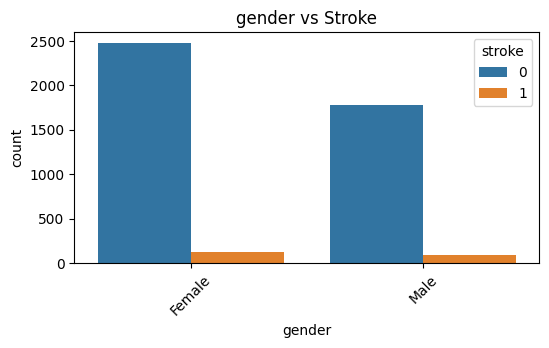

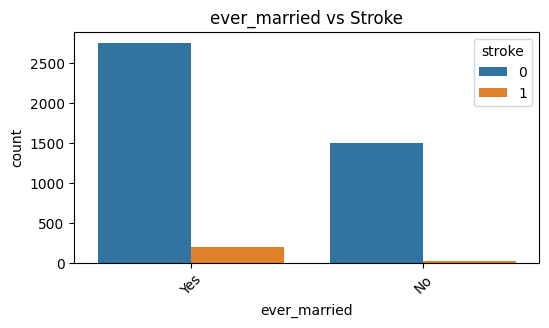

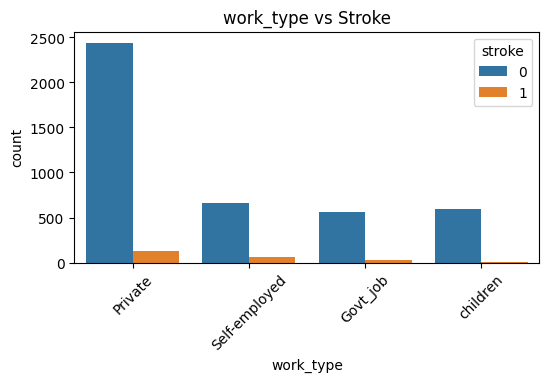

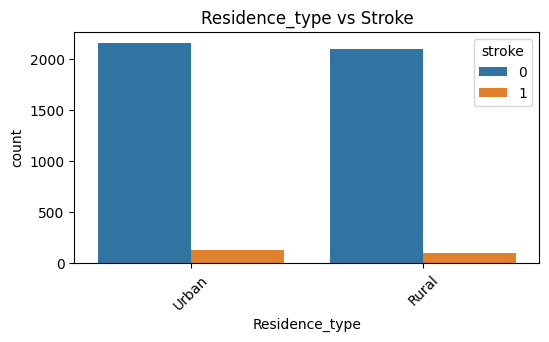

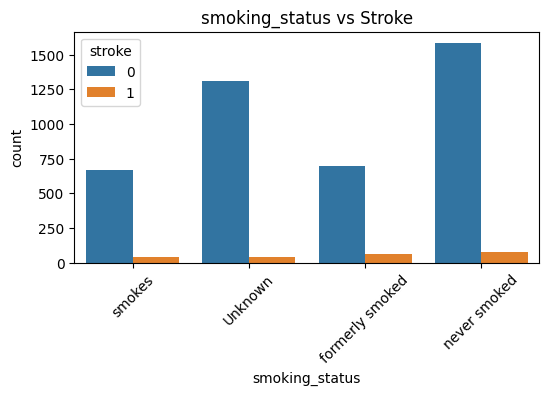

In [38]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, hue="stroke", data=df)
    plt.title(f"{col} vs Stroke")
    plt.xticks(rotation=45)
    plt.show()

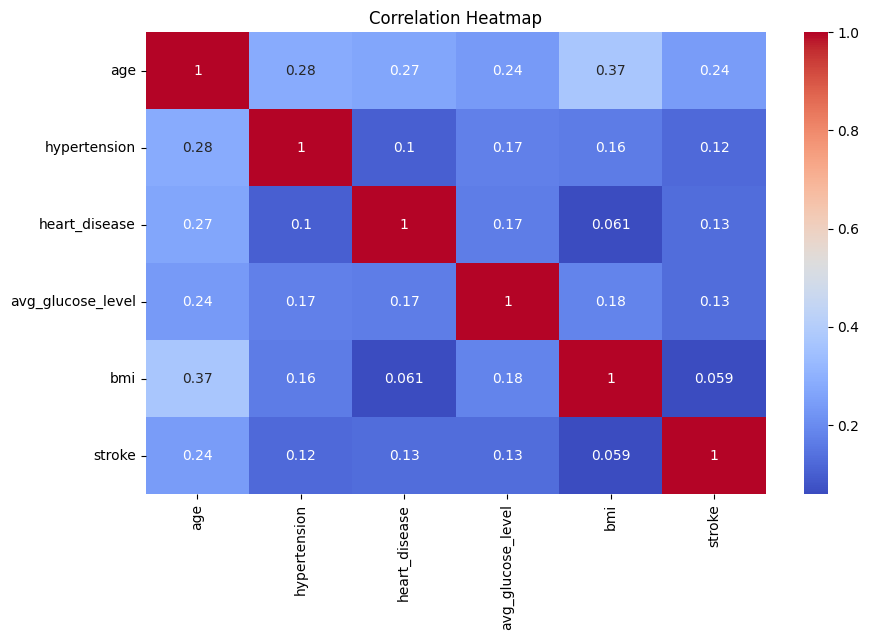

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<Axes: >

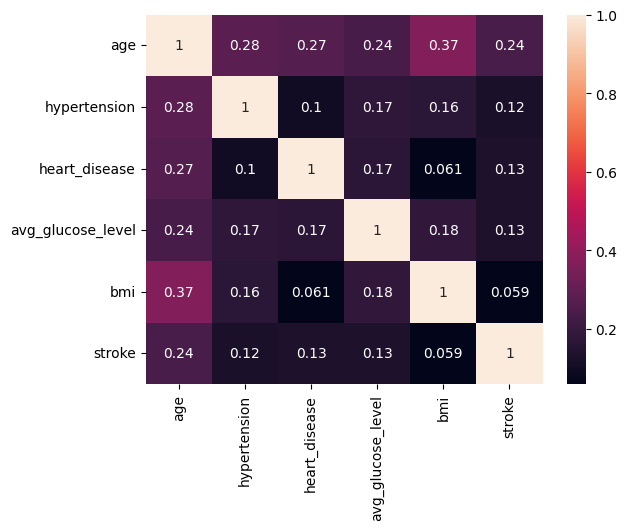

In [41]:
sns.heatmap(df.select_dtypes(include = "number").corr(), annot=True)

**EDA**